In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Load dataset
df = pd.read_csv('../data/processed/cleaned_transactions.csv')

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

/Users/rouman/Desktop/Fraud_Detection/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [3]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_smote, y_train_smote)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Models trained successfully!")

Models trained successfully!


In [4]:
# Logistic Regression Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Random Forest Predictions
rf_pred = rf_model.predict(X_test_scaled)

In [5]:
print("LOGISTIC REGRESSION RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1 Score:",
      f1_score(y_test, lr_pred))

LOGISTIC REGRESSION RESULTS

Accuracy: 0.9741055440469084
Precision: 0.057803468208092484
Recall: 0.9183673469387755
F1 Score: 0.10876132930513595


In [6]:
print("RANDOM FOREST RESULTS")
print()

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

RANDOM FOREST RESULTS

Accuracy: 0.9994908886626171
Precision: 0.8709677419354839
Recall: 0.826530612244898
F1 Score: 0.8481675392670157


In [7]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     56864
         1.0       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



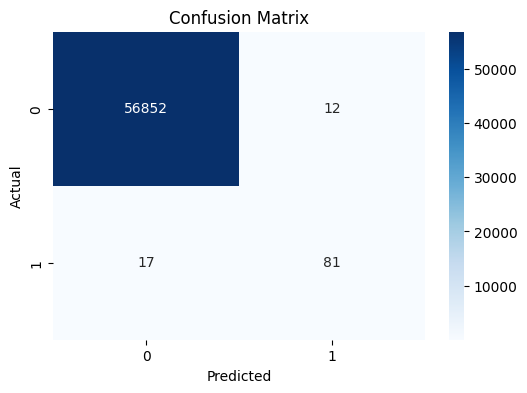

In [8]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("../reports/figures/confusion_matrix.png")
plt.show()

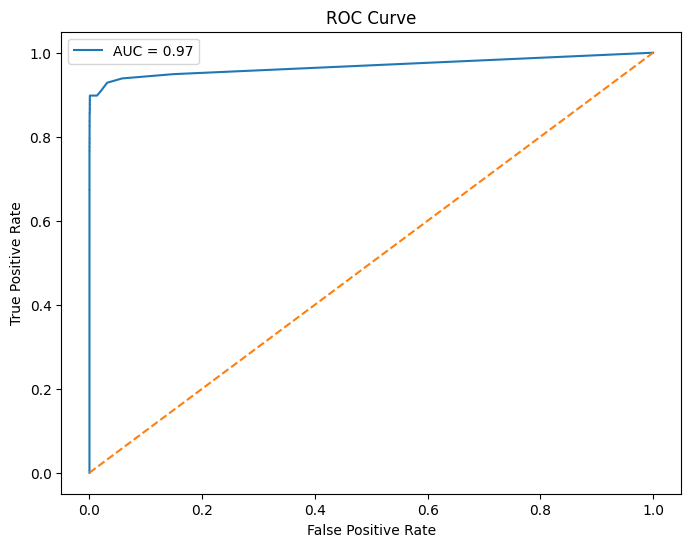

In [9]:
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()
plt.savefig("../reports/figures/roc_curve.png")
plt.show()

In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Classification report
report = classification_report(y_test, y_pred)

# Save txt report
with open('../reports/model_report.txt', 'w') as f:
    f.write("RANDOM FOREST MODEL REPORT\n\n")
    f.write(report)

print("Model report saved!")

Model report saved!
